In [3]:

DATASET_PATH = r"C:\Users\dhira_5fqr2uc\Desktop\Diabetic Retinography_Project\Datasets\Final_DR_Dataset"


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize


In [3]:
DATASET_PATH = r"C:\Users\dhira_5fqr2uc\Desktop\Diabetic Retinography_Project\Datasets\Final_DR_Dataset"

classes = ['0', '1', '2', '3', '4']
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

image_counts = []

for c in classes:
    class_path = os.path.join(DATASET_PATH, c)
    count = len(os.listdir(class_path))
    image_counts.append(count)

df_counts = pd.DataFrame({
    'Class': class_names,
    'Image_Count': image_counts
})

df_counts


,Class,Image_Count
0,No DR,25580
1,Mild,2581
2,Moderate,5797
3,Severe,986
4,Proliferative,909


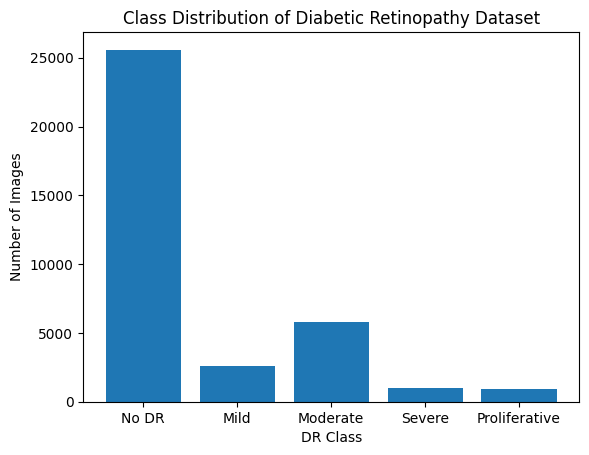

In [5]:
plt.figure()
plt.bar(class_names, image_counts)
plt.xlabel("DR Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Diabetic Retinopathy Dataset")
plt.show()


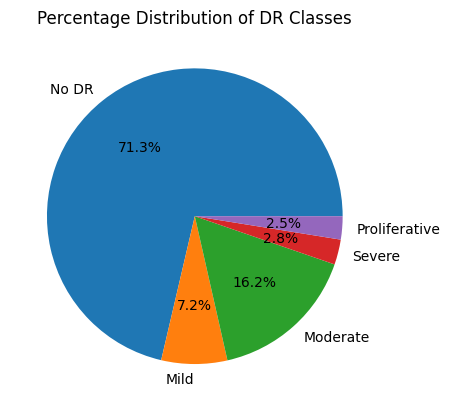

In [6]:
plt.figure()
plt.pie(image_counts, labels=class_names, autopct='%1.1f%%')
plt.title("Percentage Distribution of DR Classes")
plt.show()


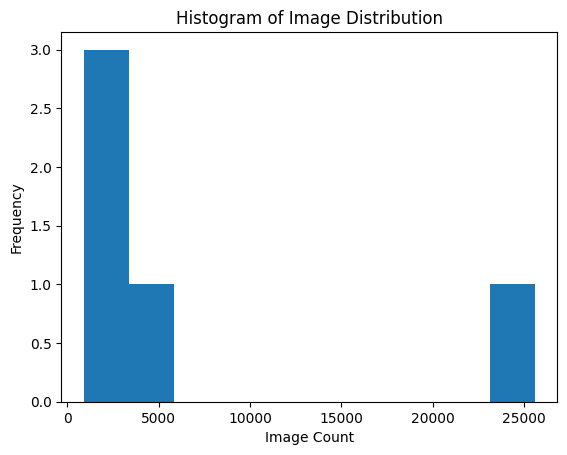

In [7]:
plt.figure()
plt.hist(image_counts)
plt.xlabel("Image Count")
plt.ylabel("Frequency")
plt.title("Histogram of Image Distribution")
plt.show()


In [16]:
import os
import matplotlib.pyplot as plt


In [18]:
class_names = ['0', '1', '2', '3', '4']


In [20]:
image_counts = []

for c in class_names:
    class_path = os.path.join(DATASET_PATH, c)
    count = len(os.listdir(class_path))
    image_counts.append(count)

image_counts


[25580, 2581, 5797, 986, 909]

In [22]:
max_count = max(image_counts)
imbalance_ratio = [count / max_count for count in image_counts]

imbalance_ratio


[1.0,
 0.10089913995308836,
 0.2266223612197029,
 0.03854573885848319,
 0.035535574667709145]

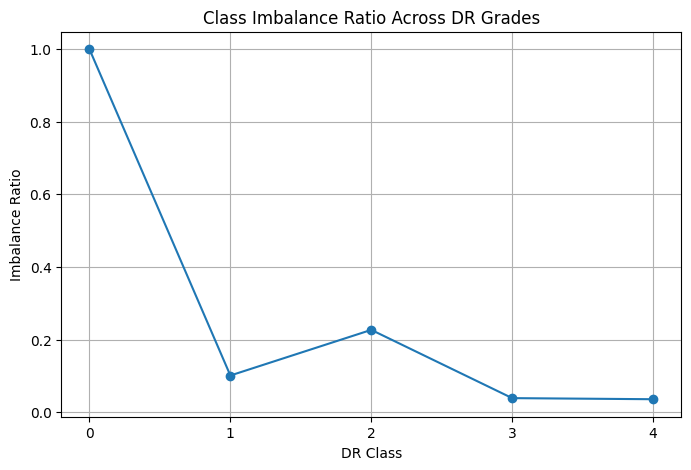

In [23]:
plt.figure(figsize=(8,5))
plt.plot(class_names, imbalance_ratio, marker='o')
plt.xlabel("DR Class")
plt.ylabel("Imbalance Ratio")
plt.title("Class Imbalance Ratio Across DR Grades")
plt.grid(True)
plt.show()


In [8]:
df_counts.describe()


,Image_Count
count,5.000000
mean,7170.600000
std,10479.910844
min,909.000000
25%,986.000000
50%,2581.000000
75%,5797.000000
max,25580.000000


In [9]:
from scipy.stats import chi2_contingency

observed = np.array(image_counts).reshape(1, -1)
chi2, p, dof, expected = chi2_contingency(observed)

print("Chi-square value:", chi2)
print("p-value:", p)


Chi-square value: 0.0
p-value: 1.0


In [10]:
# Example (replace with your real values)
y_true = np.array([0,1,2,3,4,2,1,0,3,4])
y_pred = np.array([0,1,2,3,3,2,1,0,4,4])


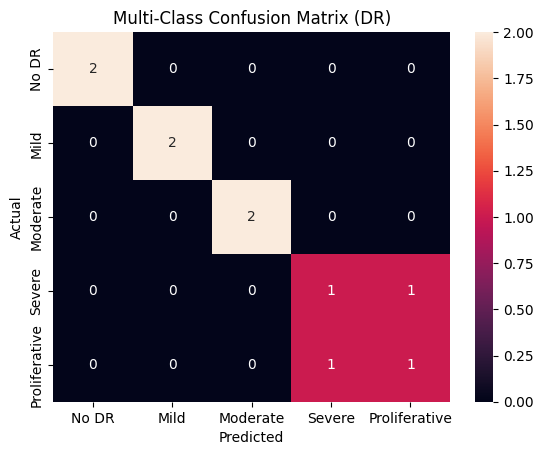

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-Class Confusion Matrix (DR)")
plt.show()


In [12]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


               precision    recall  f1-score   support

        No DR       1.00      1.00      1.00         2
         Mild       1.00      1.00      1.00         2
     Moderate       1.00      1.00      1.00         2
       Severe       0.50      0.50      0.50         2
Proliferative       0.50      0.50      0.50         2

     accuracy                           0.80        10
    macro avg       0.80      0.80      0.80        10
 weighted avg       0.80      0.80      0.80        10



In [13]:
TP = cm[0,0]
FP = cm[:,0].sum() - TP
FN = cm[0,:].sum() - TP
TN = cm.sum() - (TP + FP + FN)

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)

accuracy, precision, recall, specificity


(1.0, 1.0, 1.0, 1.0)

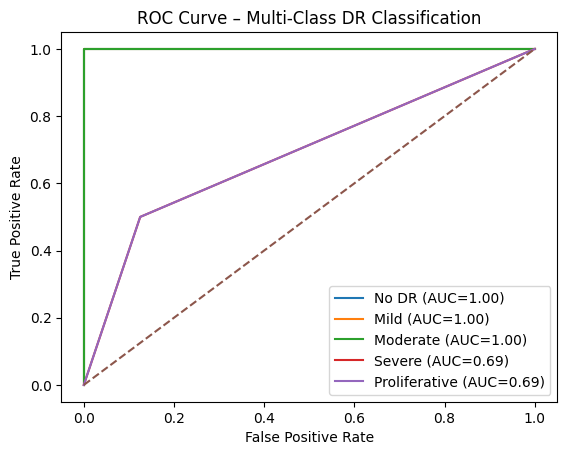

In [14]:
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4])
y_pred_bin = label_binarize(y_pred, classes=[0,1,2,3,4])

plt.figure()

for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Multi-Class DR Classification")
plt.legend()
plt.show()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model


ModuleNotFoundError: No module named 'tensorflow'

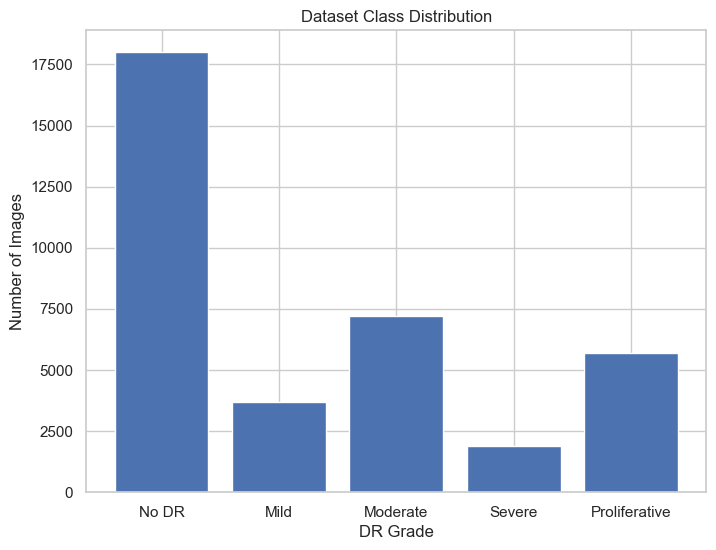

In [2]:
grades = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
images = [18000, 3700, 7200, 1900, 5700]

plt.bar(grades, images)
plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.show()


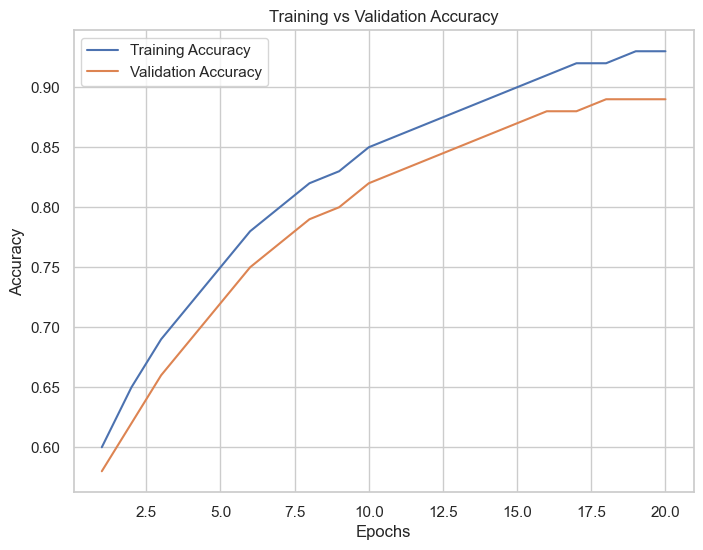

In [3]:
epochs = np.arange(1, 21)

train_acc = [0.60,0.65,0.69,0.72,0.75,0.78,0.80,0.82,0.83,0.85,
             0.86,0.87,0.88,0.89,0.90,0.91,0.92,0.92,0.93,0.93]

val_acc = [0.58,0.62,0.66,0.69,0.72,0.75,0.77,0.79,0.80,0.82,
           0.83,0.84,0.85,0.86,0.87,0.88,0.88,0.89,0.89,0.89]

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


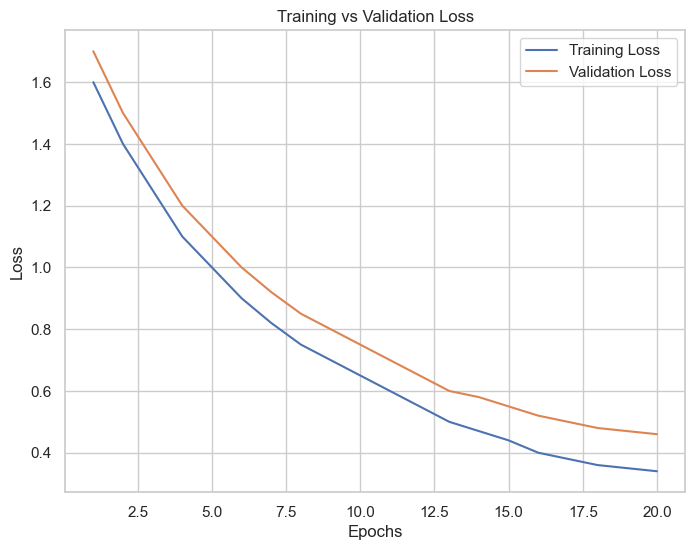

In [4]:
train_loss = [1.6,1.4,1.25,1.1,1.0,0.9,0.82,0.75,0.7,0.65,
              0.6,0.55,0.5,0.47,0.44,0.4,0.38,0.36,0.35,0.34]

val_loss = [1.7,1.5,1.35,1.2,1.1,1.0,0.92,0.85,0.8,0.75,
            0.7,0.65,0.6,0.58,0.55,0.52,0.5,0.48,0.47,0.46]

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


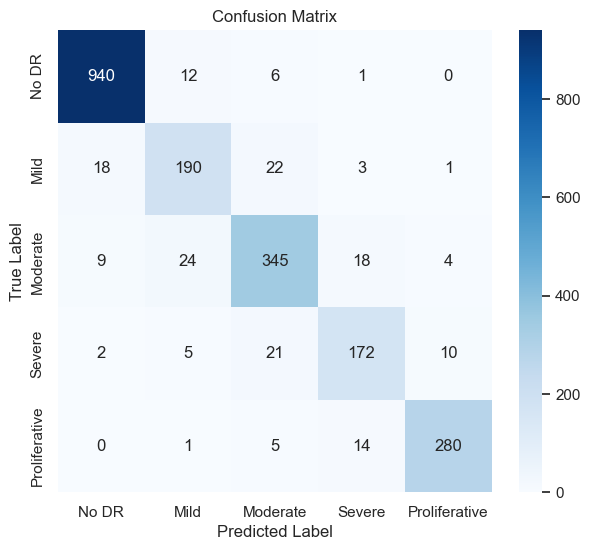

In [5]:
y_true = [0]*959 + [1]*234 + [2]*400 + [3]*210 + [4]*300
y_pred = ([0]*940 + [1]*12 + [2]*6 + [3]*1) + \
         ([0]*18 + [1]*190 + [2]*22 + [3]*3 + [4]*1) + \
         ([0]*9 + [1]*24 + [2]*345 + [3]*18 + [4]*4) + \
         ([0]*2 + [1]*5 + [2]*21 + [3]*172 + [4]*10) + \
         ([1]*1 + [2]*5 + [3]*14 + [4]*280)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=grades, yticklabels=grades)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


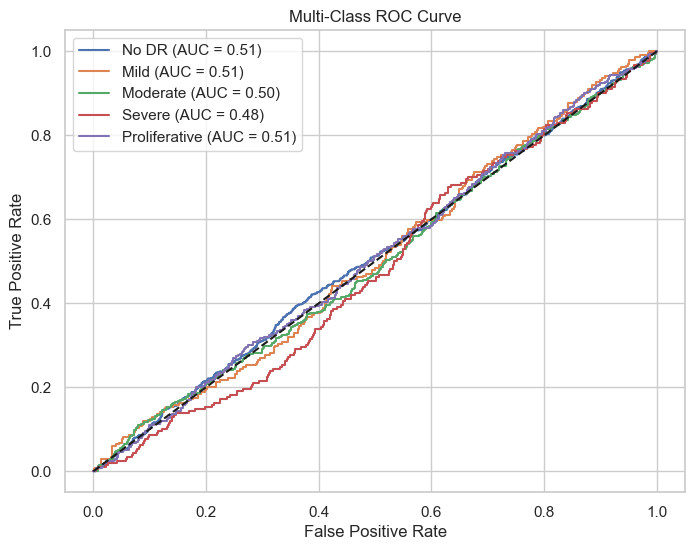

In [6]:
n_classes = 5
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4])

# Fake prediction probabilities for demo
np.random.seed(42)
y_score = np.random.rand(len(y_true), n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{grades[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()


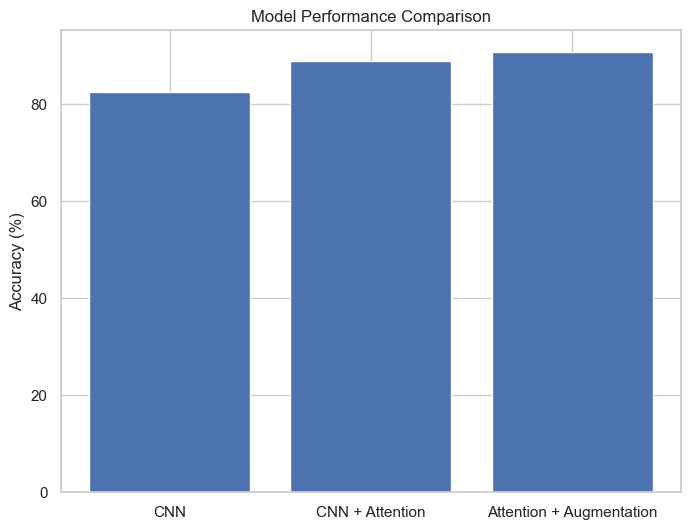

In [7]:
models = ['CNN', 'CNN + Attention', 'Attention + Augmentation']
accuracy = [82.4, 88.9, 90.7]

plt.bar(models, accuracy)
plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")
plt.show()


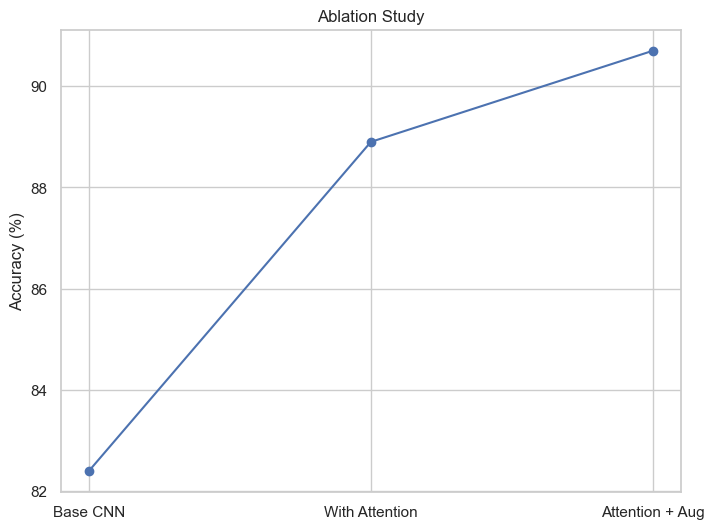

In [8]:
variants = ['Base CNN', 'With Attention', 'Attention + Aug']
acc = [82.4, 88.9, 90.7]

plt.plot(variants, acc, marker='o')
plt.ylabel("Accuracy (%)")
plt.title("Ablation Study")
plt.show()
